# Week 1: Regression, Multicollinearity, and Feature Types

### 1. Notebook Setup
- Import libraries  
- Define helper functions (e.g., for VIF calculation, model evaluation, encoding categorical variables)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Helper: VIF calculation
def calculate_vif(X):
    X = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data

## 2. Dataset 1: customer_churn
### 2.1 Data Overview

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#clean/prep data
customer_churn.dropna(inplace=True) #remove null rows
customer_churn.head()
customer_churn.info()
customer_churn.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### 2.2 Exploratory Data Analysis

Categorical: Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')
Continuous: Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


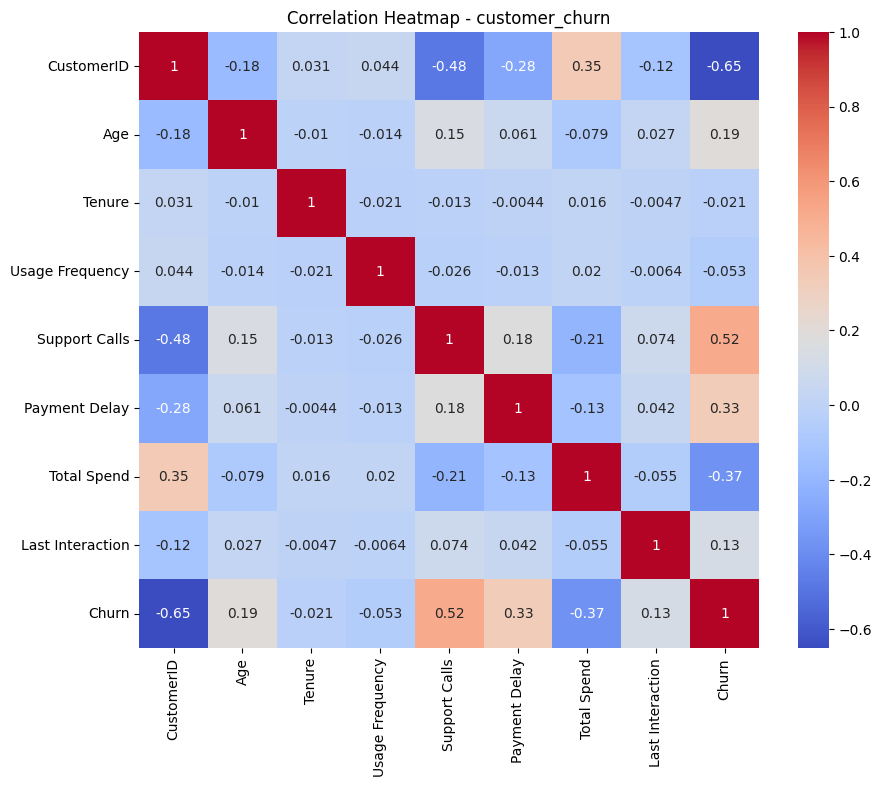

In [3]:
#separate categorical and continuous features
categorical_cols = customer_churn.select_dtypes(include=["object", "category"]).columns
continuous_cols = customer_churn.select_dtypes(include=["int64", "float64"]).columns
print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)

#correlation heatmap for continuous features
plt.figure(figsize=(10,8))
sns.heatmap(customer_churn[continuous_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - customer_churn")
plt.show()


### 2.3 Baseline Regression

In [4]:
X = customer_churn[continuous_cols].drop("churn", axis=1, errors="ignore")
y = customer_churn["churn"] if "churn" in customer_churn.columns else None

### 2.4 Polynomial Terms

In [5]:
#polynomial features on first continuous variable
if len(continuous_cols) > 0:
    feature = continuous_cols[0]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(customer_churn[[feature]])
    poly_terms = pd.DataFrame(X_poly, columns=poly.get_feature_names_out([feature])).head()
print(poly_terms)

   CustomerID  CustomerID^2
0         2.0           4.0
1         3.0           9.0
2         4.0          16.0
3         5.0          25.0
4         6.0          36.0


### 2.5 Interaction Terms

In [6]:
#interaction between first two continuous variables
if len(continuous_cols) >= 2:
    features = continuous_cols[:2]
    poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_int = poly_int.fit_transform(customer_churn[features])
    int_terms = pd.DataFrame(X_int, columns=poly_int.get_feature_names_out(features)).head()
print(int_terms)

   CustomerID   Age  CustomerID Age
0         2.0  30.0            60.0
1         3.0  65.0           195.0
2         4.0  55.0           220.0
3         5.0  58.0           290.0
4         6.0  23.0           138.0


### 2.6 Multicollinearity (VIF)

In [7]:
if len(continuous_cols) > 1:
    vif_data = calculate_vif(customer_churn[continuous_cols].dropna())
    vif_data
print(vif_data)

            feature        VIF
0             const  42.119774
1        CustomerID   1.892287
2               Age   1.045455
3            Tenure   1.001561
4   Usage Frequency   1.003554
5     Support Calls   1.433489
6     Payment Delay   1.132825
7       Total Spend   1.185966
8  Last Interaction   1.019188
9             Churn   2.094244


### 2.7 Including Categorical Features

In [8]:
customer_churn_encoded = pd.get_dummies(customer_churn, drop_first=True)
customer_churn_encoded.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


##### Relevant plots:
Polynomial relationship of Tenure vs. Churn

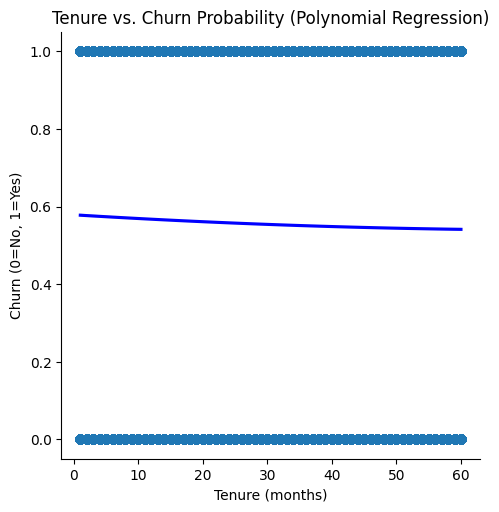

In [9]:
sns.lmplot(
    data=customer_churn,
    x='Tenure', y="Churn",
    order=2, scatter_kws={'alpha': 0.5},
    line_kws={'color':'blue'}
)
plt.title('Tenure vs. Churn Probability (Polynomial Regression)')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn (0=No, 1=Yes)')
plt.show()

## 3. Dataset 2: digital_marketing_campaign
### 3.1 Data Overview

In [14]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv", sep=',')
#remove any null rows
digital_marketing.dropna(inplace=True)
digital_marketing.head()
digital_marketing.info()
digital_marketing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


### 3.2 Exploratory Data Analysis

Categorical: Index(['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform',
       'AdvertisingTool'],
      dtype='object')
Continuous: Index(['CustomerID', 'Age', 'Income', 'AdSpend', 'ClickThroughRate',
       'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite',
       'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases',
       'LoyaltyPoints', 'Conversion'],
      dtype='object')


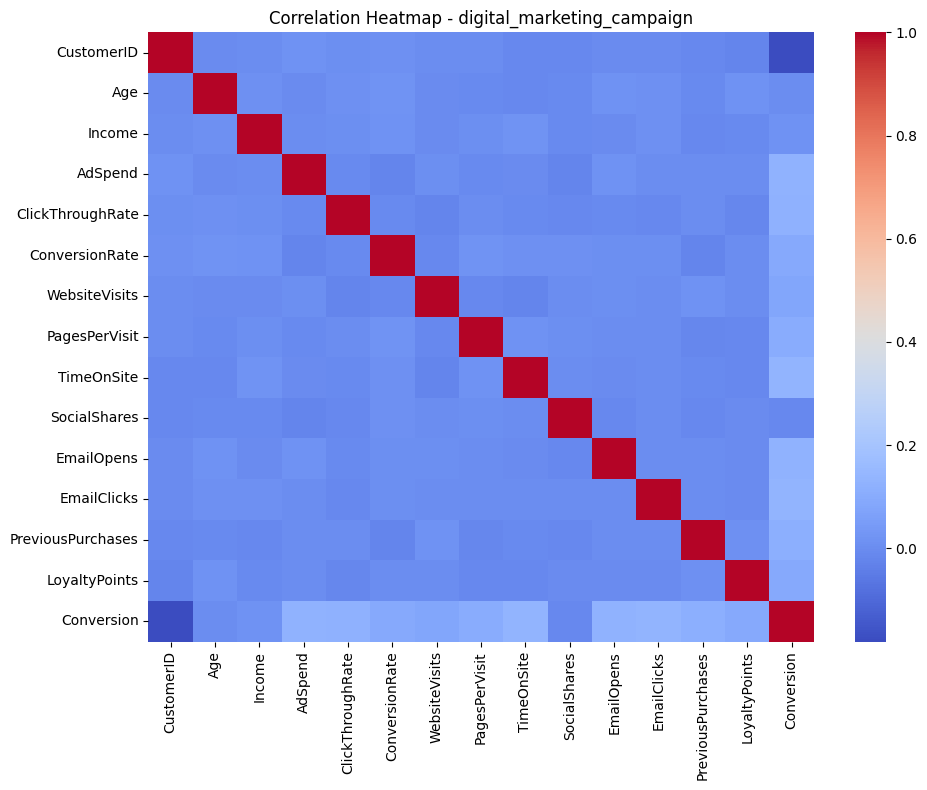

In [15]:
categorical_cols = digital_marketing.select_dtypes(include=["object", "category"]).columns
continuous_cols = digital_marketing.select_dtypes(include=["int64", "float64"]).columns
print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)

#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(digital_marketing[continuous_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap - digital_marketing_campaign")
plt.tight_layout()
plt.show()

### 3.3 Baseline Regression

In [16]:
X = digital_marketing[continuous_cols].drop("Conversion", axis=1, errors="ignore")
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

if y is not None:
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("Please define your target variable for regression.")

                            OLS Regression Results                            
Dep. Variable:             Conversion   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     109.2
Date:                Sun, 28 Sep 2025   Prob (F-statistic):          1.53e-290
Time:                        01:36:28   Log-Likelihood:                -1757.3
No. Observations:                8000   AIC:                             3545.
Df Residuals:                    7985   BIC:                             3649.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5242      0.03

### 3.4 Polynomial Terms

In [17]:
if len(continuous_cols) > 0:
    feature = continuous_cols[0]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(digital_marketing[[feature]])
    poly_terms = pd.DataFrame(X_poly, columns=poly.get_feature_names_out([feature])).head()
print(poly_terms)

   CustomerID  CustomerID^2
0      8000.0    64000000.0
1      8001.0    64016001.0
2      8002.0    64032004.0
3      8003.0    64048009.0
4      8004.0    64064016.0


### 3.5 Interaction Terms

In [18]:
if len(continuous_cols) >= 2:
    features = continuous_cols[:2]
    poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_int = poly_int.fit_transform(digital_marketing[features])
    int_terms = pd.DataFrame(X_int, columns=poly_int.get_feature_names_out(features)).head()
    print(int_terms)

   CustomerID   Age  CustomerID Age
0      8000.0  56.0        448000.0
1      8001.0  69.0        552069.0
2      8002.0  46.0        368092.0
3      8003.0  32.0        256096.0
4      8004.0  60.0        480240.0


### 3.6 Multicollinearity (VIF)

In [19]:
if len(continuous_cols) > 1:
    vif_data = calculate_vif(digital_marketing[continuous_cols].dropna())
    vif_data
print(vif_data)

              feature        VIF
0               const  80.442354
1          CustomerID   1.039336
2                 Age   1.001558
3              Income   1.001256
4             AdSpend   1.021343
5    ClickThroughRate   1.021577
6      ConversionRate   1.013832
7       WebsiteVisits   1.009957
8       PagesPerVisit   1.014272
9          TimeOnSite   1.021967
10       SocialShares   1.001415
11         EmailOpens   1.018624
12        EmailClicks   1.020154
13  PreviousPurchases   1.016422
14      LoyaltyPoints   1.012266
15         Conversion   1.191502


### 3.7 Including Categorical Features

In [20]:
digital_marketing_encoded = pd.get_dummies(digital_marketing, drop_first=True)
digital_marketing_encoded.head()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,...,LoyaltyPoints,Conversion,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,8000,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,...,688,1,False,False,False,False,True,False,False,False
1,8001,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,...,3459,1,True,False,False,False,False,False,False,True
2,8002,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,...,2337,1,False,True,False,False,False,False,False,False
3,8003,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,...,2463,1,False,True,False,False,False,False,True,False
4,8004,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,...,4345,1,False,True,False,False,False,False,True,False


## 4. Dataset 3: marketing_campaign (Optional for Week 1)
### 4.1 Data Overview

In [24]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=";")
#remove any null rows
marketing_campaign.dropna(inplace=True)
marketing_campaign.head()
marketing_campaign.info()
marketing_campaign.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### 4.2 Exploratory Data Analysis

Categorical: Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')
Continuous: Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response'],
      dtype='object')


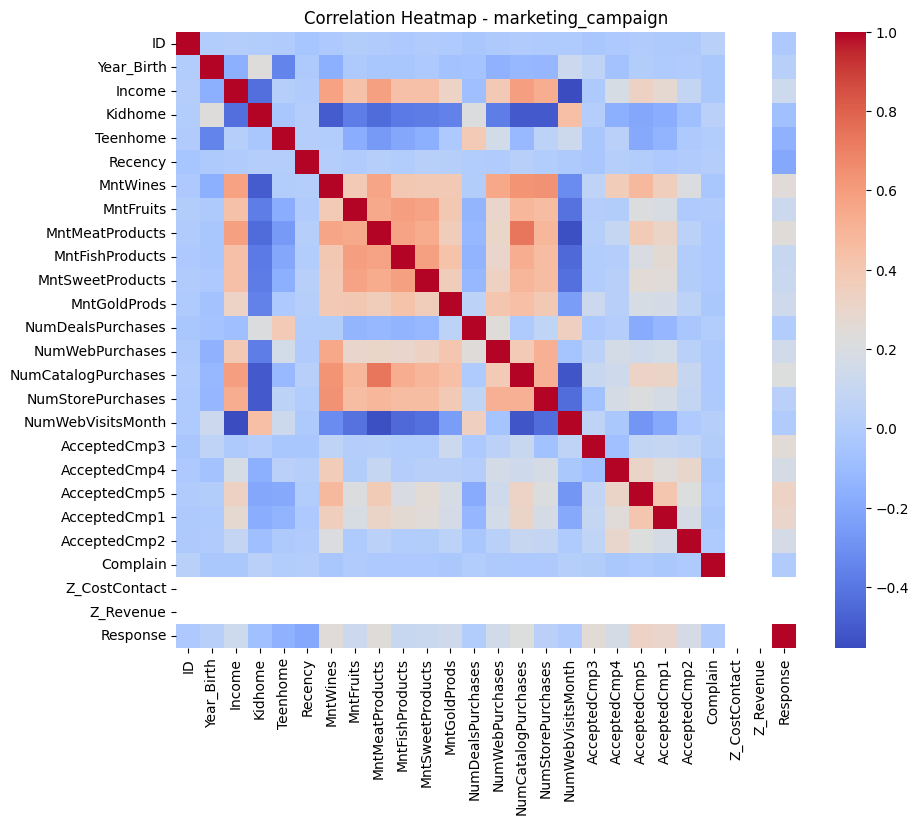

In [25]:
categorical_cols = marketing_campaign.select_dtypes(include=["object", "category"]).columns
continuous_cols = marketing_campaign.select_dtypes(include=["int64", "float64"]).columns
print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)

#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(marketing_campaign[continuous_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap - marketing_campaign")
plt.show()


### 4.3 Baseline Regression

In [26]:
X = marketing_campaign[continuous_cols].drop("Response", axis=1, errors="ignore")
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

if y is not None:
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("Please define your target variable for regression.")

                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     37.99
Date:                Sun, 28 Sep 2025   Prob (F-statistic):          2.97e-141
Time:                        01:37:43   Log-Likelihood:                -492.23
No. Observations:                2216   AIC:                             1032.
Df Residuals:                    2192   BIC:                             1169.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
ID                  -1.472e-06    

### 4.4 Polynomial Terms

In [27]:
if len(continuous_cols) > 0:
    feature = continuous_cols[0]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(marketing_campaign[[feature]])
    poly_terms = pd.DataFrame(X_poly, columns=poly.get_feature_names_out([feature])).head()
print(poly_terms)

       ID        ID^2
0  5524.0  30514576.0
1  2174.0   4726276.0
2  4141.0  17147881.0
3  6182.0  38217124.0
4  5324.0  28344976.0


### 4.5 Interaction Terms

In [28]:

if len(continuous_cols) >= 2:
    features = continuous_cols[:2]
    poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_int = poly_int.fit_transform(marketing_campaign[features])
    int_terms = pd.DataFrame(X_int, columns=poly_int.get_feature_names_out(features)).head()
print(int_terms)

       ID  Year_Birth  ID Year_Birth
0  5524.0      1957.0     10810468.0
1  2174.0      1954.0      4247996.0
2  4141.0      1965.0      8137065.0
3  6182.0      1984.0     12265088.0
4  5324.0      1981.0     10546844.0


### 4.6 Multicollinearity (VIF)

In [29]:
if len(continuous_cols) > 1:
    vif_data = calculate_vif(marketing_campaign[continuous_cols].dropna())
    vif_data
print(vif_data)

                feature       VIF
0                    ID  1.010519
1            Year_Birth  1.239822
2                Income  2.209313
3               Kidhome  1.888265
4              Teenhome  1.616396
5               Recency  1.064224
6              MntWines  3.354070
7             MntFruits  1.952965
8       MntMeatProducts  3.079459
9       MntFishProducts  2.128605
10     MntSweetProducts  1.922341
11         MntGoldProds  1.508549
12    NumDealsPurchases  1.675261
13      NumWebPurchases  1.991775
14  NumCatalogPurchases  3.112314
15    NumStorePurchases  2.443599
16    NumWebVisitsMonth  2.363545
17         AcceptedCmp3  1.160845
18         AcceptedCmp4  1.380172
19         AcceptedCmp5  1.669901
20         AcceptedCmp1  1.359485
21         AcceptedCmp2  1.160854
22             Complain  1.008155
23        Z_CostContact  0.000000
24            Z_Revenue  0.000000
25             Response  1.398602


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


### 4.7 Including Categorical Features

In [30]:
marketing_campaign_encoded = pd.get_dummies(marketing_campaign, drop_first=True)
marketing_campaign_encoded.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Dt_Customer_2014-06-20,Dt_Customer_2014-06-21,Dt_Customer_2014-06-22,Dt_Customer_2014-06-23,Dt_Customer_2014-06-24,Dt_Customer_2014-06-25,Dt_Customer_2014-06-26,Dt_Customer_2014-06-27,Dt_Customer_2014-06-28,Dt_Customer_2014-06-29
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,False,False,False,False,False,False,False,False,False,False
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,False,False,False,False,False,False,False,False,False,False
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,False,False,False,False,False,False,False,False,False,False
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,False,False,False,False,False,False,False,False,False,False
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,False,False,False,False,False,False,False,False,False,False
